# 01 EDA — 데이터 품질과 5가지 질문
- 데이터: MIT-Stanford Battery Dataset (Severson et al., Nature Energy 2019), Batch 1 · 2 · 3
- 과제 선택: **Regression** — 초기 100사이클 데이터로 `cycle_life` 예측
- 순서: 데이터 품질 → ① 수명 분포 → ② 열화 곡선 · Knee → ③ ΔQ(V) → ④ 충전 조건 → ⑤ 상관관계 → ⑥ 셀 편차
- 배치 간 비교는 분포를 보는 데만 쓰고, 피처 · 모델 결정의 근거는 학습 배치(B1)에서만 계산한다
- 사전 준비: `python src/preprocess.py` → `python src/features.py`

In [1]:
import pickle, sys, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm, colors as mcolors
sys.path.insert(0, '../src')
from config import EOL_AH
from features import build_table, knee_point, delta_q
from preprocess import valid_qd
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
plt.rcParams.update({'font.family': 'AppleGothic', 'axes.unicode_minus': False, 'font.size': 15, 'axes.titlesize': 15, 'axes.labelsize': 15, 'xtick.labelsize': 13, 'ytick.labelsize': 13, 'legend.fontsize': 13,
                     'axes.spines.top': False, 'axes.spines.right': False, 'figure.dpi': 110})
BC = {'b1': '#2563eb', 'b2': '#ea580c', 'b3': '#0d9488'}
BN = {'b1': 'Batch 1 (학습)', 'b2': 'Batch 2 (테스트)', 'b3': 'Batch 3 (추가 검증)'}
FIG = '../results/figures'

cells = []
for k in ['b1', 'b2', 'b3']:
    cells += pickle.load(open(f'../data/processed/{k}.pkl', 'rb'))
by_id = {c['cell_id']: c for c in cells}
df = build_table(cells)
used = df[df.status == 'used'].copy()
print(df.groupby(['batch', 'status']).size().unstack(fill_value=0))

status  censored  missing  used
batch                          
b1            10        0    36
b2             0        8    39
b3             0        2    44


## 0. 데이터 품질 — 수명 라벨을 믿을 수 있는가?
- 라벨 정의 검증: 방전용량이 0.88Ah(정격 1.1Ah의 80%)에 닿는 사이클을 다시 계산해 제공 라벨과 비교
- EOL 전에 실험이 끝난 셀(censored)과 라벨 없는 특수 실험 셀(missing) 식별

findfont: Failed to find font weight bold for AppleGothic, now using 400.


라벨 재계산 일치: 119 / 119 셀
B1 censored: ['b1c0', 'b1c1', 'b1c2', 'b1c3', 'b1c4', 'b1c8', 'b1c10', 'b1c12', 'b1c13', 'b1c22'] 
마지막 용량(Ah): [np.float64(1.027), np.float64(1.039), np.float64(1.044), np.float64(0.972), np.float64(1.022), np.float64(0.97), np.float64(0.962), np.float64(0.915), np.float64(0.925), np.float64(0.965)]
missing: cell_id                      policy  n_cycles
  b2c22      VarCharge-2C-100cycles       920
  b2c23      VarCharge-4C-100cycles      1152
  b2c35      VarCharge-6C-100cycles       423
  b2c36      VarCharge-8C-100cycles       280
  b2c37    3.6C(80%)-3.6C(SLOWCYCLE       101
  b2c38    4.8C(80%)-4.8C(SLOWCYCLE       101
  b2c39       3.6C(9%)-5C(SLOWCYCLE       434
  b2c40      5.2C(58%)-4C(SLOWCYCLE       459
  b3c23 4.8C(80%)-4.8C-newstructure      2189
  b3c32 4.8C(80%)-4.8C-newstructure      2237


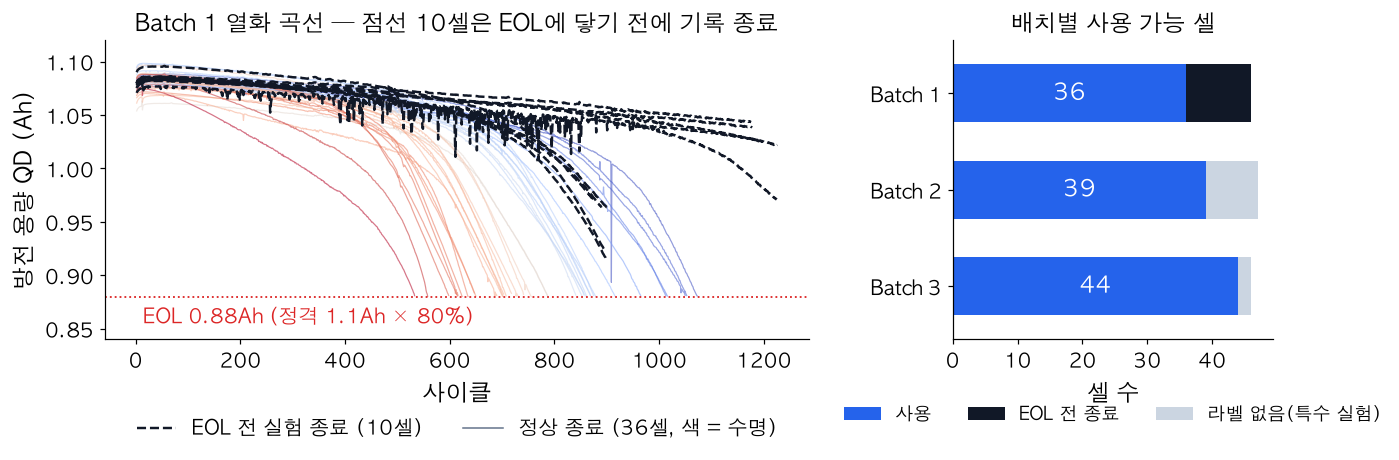

In [2]:
chk = used.eol_cycle_calc - used.cycle_life_raw
print(f'라벨 재계산 일치: {(chk == 0).sum()} / {len(chk)} 셀')
cen = df[df.status == 'censored']
print('B1 censored:', list(cen.cell_id), '\n마지막 용량(Ah):',
      [round(np.nanmean(valid_qd(by_id[c])[-5:]), 3) for c in cen.cell_id])
print('missing:', df[df.status == 'missing'][['cell_id', 'policy', 'n_cycles']].to_string(index=False))

fig, ax = plt.subplots(1, 2, figsize=(13, 4.6), gridspec_kw={'width_ratios': [2.2, 1]})
b1u = used[used.batch == 'b1']
norm = mcolors.Normalize(b1u.cycle_life.min(), b1u.cycle_life.max())
for _, r in b1u.iterrows():
    q = valid_qd(by_id[r.cell_id]); ax[0].plot(np.arange(1, len(q) + 1), q, color=cm.coolwarm_r(norm(r.cycle_life)), lw=0.8, alpha=0.55)
for cid in cen.cell_id:
    q = valid_qd(by_id[cid]); ax[0].plot(np.arange(1, len(q) + 1), q, color='#111827', lw=1.6, ls='--')
ax[0].axhline(EOL_AH, color='#dc2626', lw=1.2, ls=':')
ax[0].text(15, EOL_AH - 0.025, 'EOL 0.88Ah (정격 1.1Ah × 80%)', color='#dc2626', fontsize=13)
ax[0].plot([], [], color='#111827', ls='--', lw=1.6, label=f'EOL 전 실험 종료 ({len(cen)}셀)')
ax[0].plot([], [], color='#64748b', lw=1, label='정상 종료 (36셀, 색 = 수명)')
ax[0].legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=2, frameon=False); ax[0].set_ylim(0.84, 1.12)
ax[0].set_xlabel('사이클'); ax[0].set_ylabel('방전 용량 QD (Ah)'); ax[0].set_title('Batch 1 열화 곡선 — 점선 10셀은 EOL에 닿기 전에 기록 종료')
st = df.groupby(['batch', 'status']).size().unstack(fill_value=0)[['used', 'censored', 'missing']]
st.index = ['Batch 1', 'Batch 2', 'Batch 3']
st.plot.barh(stacked=True, ax=ax[1], color=['#2563eb', '#111827', '#cbd5e1'], width=0.6)
ax[1].invert_yaxis(); ax[1].set_xlabel('셀 수'); ax[1].set_title('배치별 사용 가능 셀')
ax[1].legend(['사용', 'EOL 전 종료', '라벨 없음(특수 실험)'], frameon=False, loc='upper center', bbox_to_anchor=(0.5, -0.16), ncol=3, fontsize=12)
for i, (u_, c_, m_) in enumerate(st.values):
    ax[1].text(u_ / 2, i, str(u_), ha='center', va='center', color='white', fontweight='bold')
plt.tight_layout(); plt.savefig(f'{FIG}/e1_label_quality.png', dpi=200, bbox_inches='tight'); plt.show()

## ① Cycle Life 분포 — 배치 간 비교

findfont: Failed to find font weight bold for AppleGothic, now using 400.


       count    mean    std    min    25%     50%     75%     max
batch                                                            
b1      36.0   788.0  149.0  534.0  681.0   772.0   872.0  1074.0
b2      39.0   566.0  222.0  392.0  440.0   472.0   508.0  1186.0
b3      44.0  1060.0  314.0  541.0  828.0  1006.0  1155.0  1935.0
b1: 단수명(<500) 0 / 장수명(>1000) 5 / n=36
b2: 단수명(<500) 28 / 장수명(>1000) 3 / n=39
b3: 단수명(<500) 0 / 장수명(>1000) 23 / n=44
B2 중 학습 최솟값(534) 미만: 30 / 39 = 77%
최단 셀: cell_id      policy  cycle_life
  b2c19  6C(60%)-3C       392.0
   b2c6 3.6C(9%)-5C       393.0
  b2c15 3.6C(9%)-5C       396.0


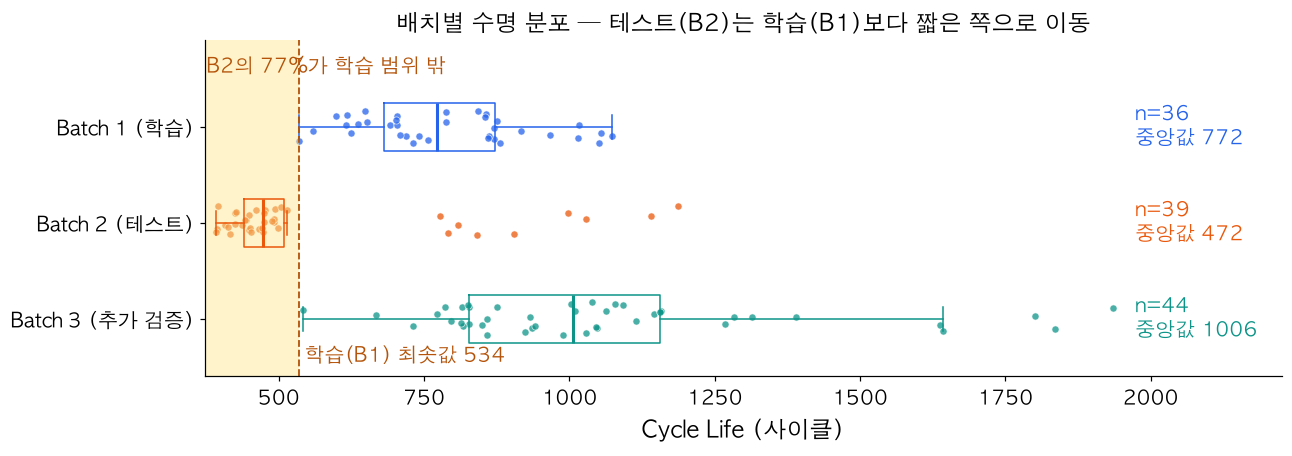

In [3]:
print(used.groupby('batch').cycle_life.describe().round(0))
for b in ['b1', 'b2', 'b3']:
    x = used[used.batch == b].cycle_life
    print(f'{b}: 단수명(<500) {(x < 500).sum()} / 장수명(>1000) {(x > 1000).sum()} / n={len(x)}')
b1min = used[used.batch == 'b1'].cycle_life.min()
b2 = used[used.batch == 'b2']
print(f'B2 중 학습 최솟값({b1min:.0f}) 미만: {(b2.cycle_life < b1min).sum()} / {len(b2)} = {(b2.cycle_life < b1min).mean():.0%}')
lo, hi = used.cycle_life.min(), used.cycle_life.max()
print('최단 셀:', used.nsmallest(3, 'cycle_life')[['cell_id', 'policy', 'cycle_life']].to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 4.4))
rng = np.random.default_rng(RANDOM_STATE)
for i, b in enumerate(['b1', 'b2', 'b3']):
    x = used[used.batch == b].cycle_life.values
    ax.boxplot(x, positions=[i], vert=False, widths=0.5, showfliers=False,
               boxprops=dict(color=BC[b]), medianprops=dict(color=BC[b], lw=2), whiskerprops=dict(color=BC[b]), capprops=dict(color=BC[b]))
    ax.scatter(x, i + rng.uniform(-0.18, 0.18, len(x)), s=22, color=BC[b], alpha=0.75, edgecolor='white', lw=0.5)
    ax.text(hi * 1.02, i, f'n={len(x)}\n중앙값 {np.median(x):.0f}', va='center', fontsize=13, color=BC[b])
ax.axvspan(lo * 0.95, b1min, color='#fde68a', alpha=0.45, lw=0)
ax.axvline(b1min, color='#b45309', ls='--', lw=1.2)
ax.text(b1min + 10, 2.45, f'학습(B1) 최솟값 {b1min:.0f}', color='#b45309', fontsize=13)
ax.text(lo * 0.96, -0.62, f'B2의 {(b2.cycle_life < b1min).mean():.0%}가 학습 범위 밖', color='#b45309', fontsize=13, fontweight='bold', va='center')
ax.set_yticks([0, 1, 2]); ax.set_yticklabels([BN[b] for b in ['b1', 'b2', 'b3']])
ax.set_ylim(2.6, -0.9); ax.set_xlabel('Cycle Life (사이클)'); ax.set_xlim(lo * 0.95, hi * 1.15)
ax.set_title('배치별 수명 분포 — 테스트(B2)는 학습(B1)보다 짧은 쪽으로 이동')
plt.tight_layout(); plt.savefig(f'{FIG}/e2_life_dist.png', dpi=200, bbox_inches='tight'); plt.show()

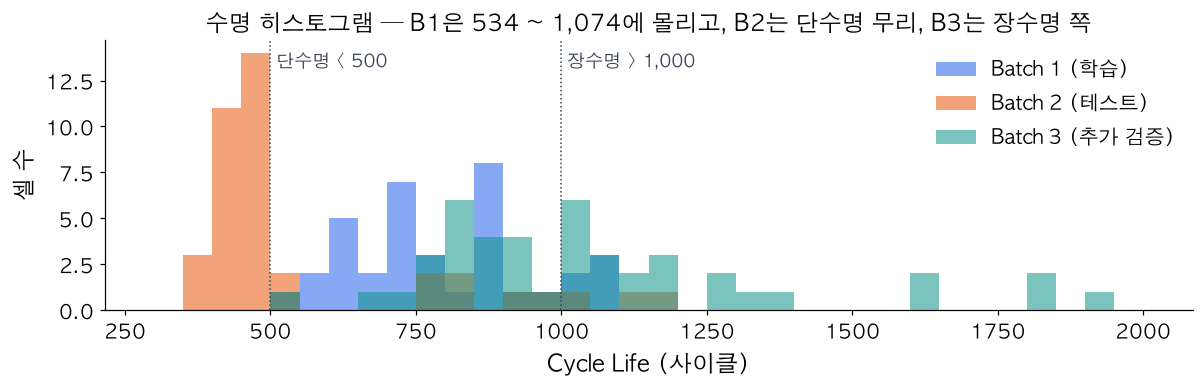

In [4]:
fig, ax = plt.subplots(figsize=(11, 3.8))
bins = np.arange(300, 2001, 50)
for b in ['b1', 'b2', 'b3']:
    ax.hist(used[used.batch == b].cycle_life, bins=bins, alpha=0.55, color=BC[b], label=BN[b])
for x, t in [(500, '단수명 < 500'), (1000, '장수명 > 1,000')]:
    ax.axvline(x, color='#374151', ls=':', lw=1); ax.text(x + 10, ax.get_ylim()[1] * 0.9, t, fontsize=12, color='#374151')
ax.set_xlabel('Cycle Life (사이클)'); ax.set_ylabel('셀 수'); ax.legend(frameon=False)
ax.set_title('수명 히스토그램 — B1은 534 ~ 1,074에 몰리고, B2는 단수명 무리, B3는 장수명 쪽')
plt.tight_layout(); plt.savefig(f'{FIG}/e2b_life_hist.png', dpi=200, bbox_inches='tight'); plt.show()

## ② 열화 곡선 — 일정한가, 가속되는가? Knee point는 언제?
- Knee 검출: 사이클별 방전 용량을 두 직선으로 나눠 맞췄을 때 제곱오차 합이 가장 작은 분기 사이클 (`features.knee_point`)

Knee/수명 중앙값 0.75 (범위 0.69~0.82), 최소 knee 414사이클
Knee 이후 열화 속도 / 이전: 중앙값 10.5배,  corr(knee, 수명) = 0.982
100사이클 시점 용량 변화(사이클 2 대비): 중앙값 +0.22%


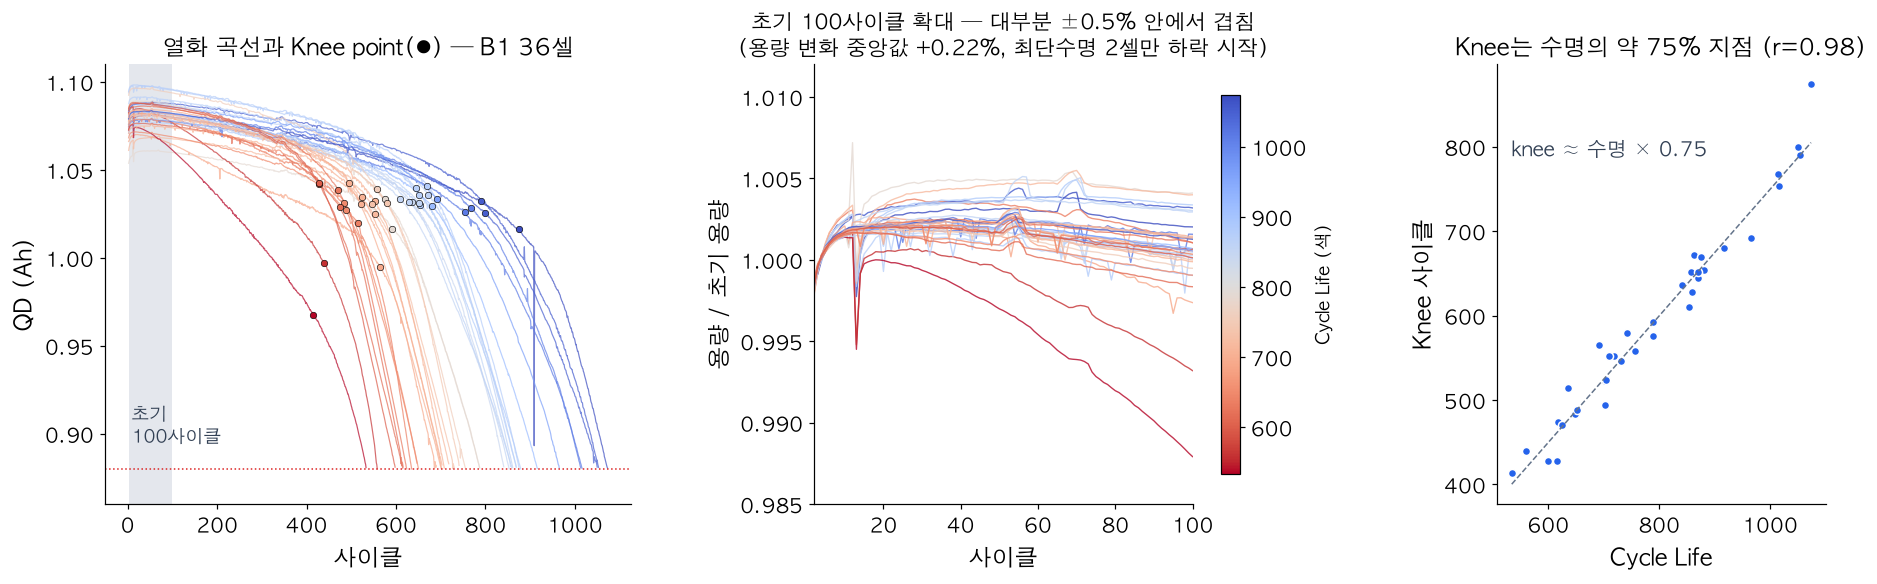

In [5]:
kd = pd.DataFrame([(c['cell_id'],) + tuple(knee_point(c)) for c in cells if c['cell_id'] in set(b1u.cell_id)],
                  columns=['cell_id', 'knee', 's_before', 's_after']).merge(b1u[['cell_id', 'cycle_life', 'qd_fade_pct_100']], on='cell_id')
kd['ratio'] = kd.knee / kd.cycle_life
print(f"Knee/수명 중앙값 {kd.ratio.median():.2f} (범위 {kd.ratio.min():.2f}~{kd.ratio.max():.2f}), 최소 knee {kd.knee.min():.0f}사이클")
print(f"Knee 이후 열화 속도 / 이전: 중앙값 {(kd.s_after / kd.s_before).median():.1f}배,  corr(knee, 수명) = {kd[['knee','cycle_life']].corr().iloc[0,1]:.3f}")
print(f"100사이클 시점 용량 변화(사이클 2 대비): 중앙값 {kd.qd_fade_pct_100.median():+.2f}%")

fig, ax = plt.subplots(1, 3, figsize=(17, 5.2), gridspec_kw={'width_ratios': [1.6, 1.15, 1], 'wspace': 0.12}, constrained_layout=True)
fig.get_layout_engine().set(w_pad=0.25)
for _, r in b1u.iterrows():
    q = valid_qd(by_id[r.cell_id]); col = cm.coolwarm_r(norm(r.cycle_life))
    ax[0].plot(np.arange(1, len(q) + 1), q, color=col, lw=0.8, alpha=0.7)
    k = kd.loc[kd.cell_id == r.cell_id, 'knee'].values[0]
    ax[0].scatter(k, np.interp(k, np.arange(1, len(q) + 1)[~np.isnan(q)], q[~np.isnan(q)]), color=col, s=18, edgecolor='black', lw=0.4, zorder=3)
ax[0].axvspan(2, 100, color='#94a3b8', alpha=0.25, lw=0); ax[0].text(8, 0.895, '초기\n100사이클', fontsize=12, color='#334155')
ax[0].axhline(EOL_AH, color='#dc2626', ls=':', lw=1)
ax[0].set_ylim(0.86, 1.11); ax[0].set_xlabel('사이클'); ax[0].set_ylabel('QD (Ah)'); ax[0].set_title('열화 곡선과 Knee point(●) — B1 36셀')
for _, r in b1u.iterrows():
    q = valid_qd(by_id[r.cell_id])[:100]; ax[1].plot(np.arange(1, 101), q / np.nanmean(q[1:6]), color=cm.coolwarm_r(norm(r.cycle_life)), lw=0.9, alpha=0.8)
ax[1].set_xlim(2, 100); ax[1].set_ylim(0.985, 1.012); ax[1].set_xlabel('사이클'); ax[1].set_ylabel('용량 / 초기 용량')
ax[1].set_title(f'초기 100사이클 확대 — 대부분 ±0.5% 안에서 겹침\n(용량 변화 중앙값 {kd.qd_fade_pct_100.median():+.2f}%, 최단수명 2셀만 하락 시작)', fontsize=14)
ax[2].scatter(kd.cycle_life, kd.knee, color='#2563eb', s=28, edgecolor='white')
xx = np.array([kd.cycle_life.min(), kd.cycle_life.max()]); ax[2].plot(xx, xx * kd.ratio.median(), color='#64748b', ls='--', lw=1)
ax[2].text(xx[0], xx[1] * kd.ratio.median() * 0.98, f'knee ≈ 수명 × {kd.ratio.median():.2f}', fontsize=13, color='#334155')
ax[2].set_xlabel('Cycle Life'); ax[2].set_ylabel('Knee 사이클'); ax[2].set_title(f'Knee는 수명의 약 {kd.ratio.median():.0%} 지점 (r={kd[["knee","cycle_life"]].corr().iloc[0,1]:.2f})')
sm = cm.ScalarMappable(norm=norm, cmap='coolwarm_r'); cb = fig.colorbar(sm, ax=ax[1], fraction=0.05, pad=0.02); cb.set_label('Cycle Life (색)', fontsize=12)
plt.savefig(f'{FIG}/e3_degradation_knee.png', dpi=200, bbox_inches='tight'); plt.show()

## ③ ΔQ(V) = Q₁₀₀(V) - Q₁₀(V) — 초기 사이클에서 차이가 보이는가?
- `Qdlin`: 방전 용량을 공통 전압 눈금(`Vdlin`, 3.5→2.0V, 1,000점)에 맞춰 다시 찍은 값 → 사이클끼리 같은 전압에서 바로 뺄 수 있음
- 장수명/단수명 셀의 ΔQ 곡선 모양 비교 → 구분 가능한 통계값(분산·최솟값·평균) 추출

b1: corr(log10 Var(ΔQ), log10 수명) = -0.844  | corr(log10|min ΔQ|) = -0.821  n=36
b2: corr(log10 Var(ΔQ), log10 수명) = -0.918  | corr(log10|min ΔQ|) = -0.901  n=39
b3: corr(log10 Var(ΔQ), log10 수명) = -0.762  | corr(log10|min ΔQ|) = -0.744  n=44
B1 단순 직선: log10(수명) = -0.297 × log10 Var(ΔQ) + 1.762
b1: 실제/직선예측 중앙값 0.99  (직선이 과대예측한 셀 19/36)
b2: 실제/직선예측 중앙값 0.76  (직선이 과대예측한 셀 38/39)
b3: 실제/직선예측 중앙값 0.98  (직선이 과대예측한 셀 25/44)
B2 단수명(<534) 30셀: 실제/직선예측 중앙값 0.76


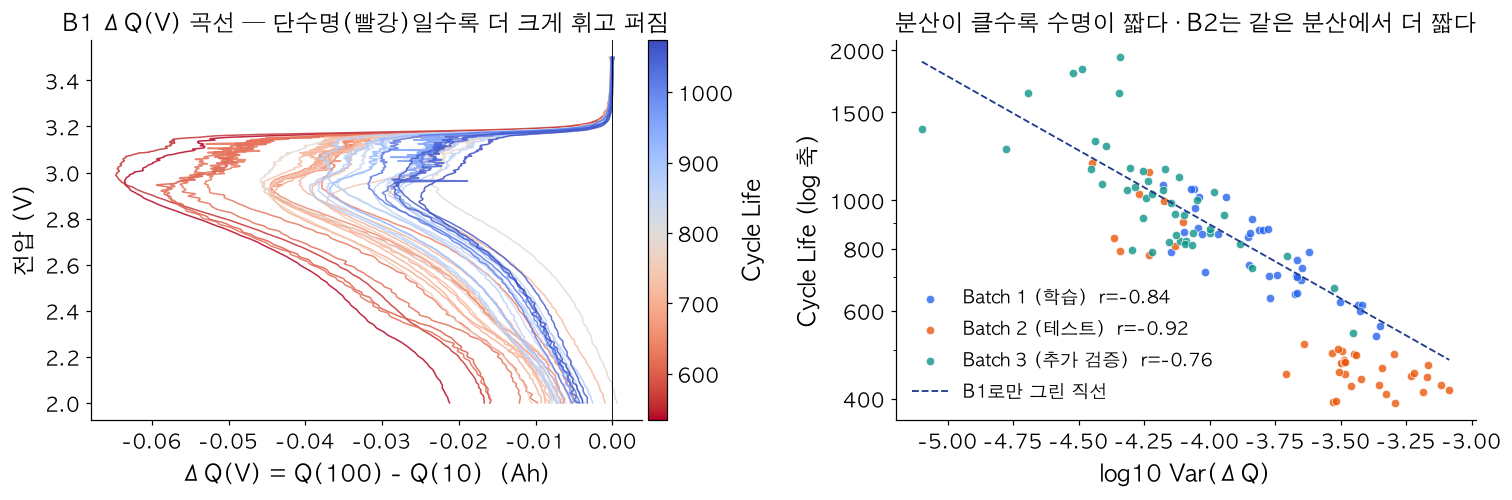

In [6]:
V = cells[0]['vdlin']
for b in ['b1', 'b2', 'b3']:
    x = used[used.batch == b]
    print(f"{b}: corr(log10 Var(ΔQ), log10 수명) = {x[['dq_var_log','log_life']].corr().iloc[0,1]:.3f}  | corr(log10|min ΔQ|) = {x[['dq_min_log','log_life']].corr().iloc[0,1]:.3f}  n={len(x)}")
fit = np.polyfit(used[used.batch == 'b1'].dq_var_log, used[used.batch == 'b1'].log_life, 1)
print(f'B1 단순 직선: log10(수명) = {fit[0]:.3f} × log10 Var(ΔQ) + {fit[1]:.3f}')
for b in ['b1', 'b2', 'b3']:
    x = used[used.batch == b]; ratio = x.cycle_life / 10 ** np.polyval(fit, x.dq_var_log)
    print(f'{b}: 실제/직선예측 중앙값 {ratio.median():.2f}  (직선이 과대예측한 셀 {(ratio < 1).sum()}/{len(x)})')
x = used[(used.batch == 'b2') & (used.cycle_life < 534)]; ratio = x.cycle_life / 10 ** np.polyval(fit, x.dq_var_log)
print(f'B2 단수명(<534) {len(x)}셀: 실제/직선예측 중앙값 {ratio.median():.2f}')

fig, ax = plt.subplots(1, 2, figsize=(14, 4.8))
for _, r in b1u.sort_values('cycle_life').iterrows():
    ax[0].plot(delta_q(by_id[r.cell_id]), V, color=cm.coolwarm_r(norm(r.cycle_life)), lw=1, alpha=0.85)
ax[0].axvline(0, color='black', lw=0.6); ax[0].set_xlabel('ΔQ(V) = Q(100) - Q(10)  (Ah)'); ax[0].set_ylabel('전압 (V)')
ax[0].set_title('B1 ΔQ(V) 곡선 — 단수명(빨강)일수록 더 크게 휘고 퍼짐')
fig.colorbar(cm.ScalarMappable(norm=norm, cmap='coolwarm_r'), ax=ax[0], fraction=0.04, pad=0.01, label='Cycle Life')
for b in ['b1', 'b2', 'b3']:
    x = used[used.batch == b]
    r_ = x[['dq_var_log', 'log_life']].corr().iloc[0, 1]
    ax[1].scatter(x.dq_var_log, x.cycle_life, s=30, color=BC[b], alpha=0.8, edgecolor='white', lw=0.5, label=f'{BN[b]}  r={r_:.2f}')
xs = np.linspace(used.dq_var_log.min(), used.dq_var_log.max(), 50)
ax[1].plot(xs, 10 ** np.polyval(fit, xs), color='#1e3a8a', ls='--', lw=1.2, label='B1로만 그린 직선')
ax[1].set_yscale('log'); ax[1].set_yticks([400, 600, 800, 1000, 1500, 2000]); ax[1].set_yticklabels(['400', '600', '800', '1000', '1500', '2000'])
ax[1].set_xlabel('log10 Var(ΔQ)'); ax[1].set_ylabel('Cycle Life (log 축)')
ax[1].set_title('분산이 클수록 수명이 짧다 · B2는 같은 분산에서 더 짧다'); ax[1].legend(frameon=False, fontsize=12)
plt.tight_layout(); plt.savefig(f'{FIG}/e4_delta_q.png', dpi=200, bbox_inches='tight'); plt.show()

## ④ 충전 조건(C-rate)과 수명

b1: corr(충전시간 2~6, log수명) = 0.575 | corr(C1, log수명) = -0.238 | 정책 20종 / 36셀
b2: corr(충전시간 2~6, log수명) = -0.942 | corr(C1, log수명) = 0.196 | 정책 12종 / 39셀
b3: corr(충전시간 2~6, log수명) = 0.601 | corr(C1, log수명) = 0.018 | 정책 8종 / 44셀
B1 정책당 셀 수: {2: 16, 1: 4}
                 mean  count
policy                      
5.4C(80%)-5.4C  546.5      2
8C(35%)-3.6C    607.5      2
7C(40%)-3.6C    621.0      2
                  mean  count
policy                       
6C(30%)-3.6C    1014.0      1
5.4C(40%)-3.6C  1054.0      1
4.4C(80%)-4.4C  1074.0      1
       count   mean   std    min    25%    50%    75%    max
batch                                                       
b1      36.0  10.74  0.81   8.96  10.13  10.78  11.19  12.15
b2      39.0  10.15  0.06  10.04  10.17  10.17  10.18  10.22
b3      44.0  10.18  0.35  10.04  10.04  10.04  10.05  11.05


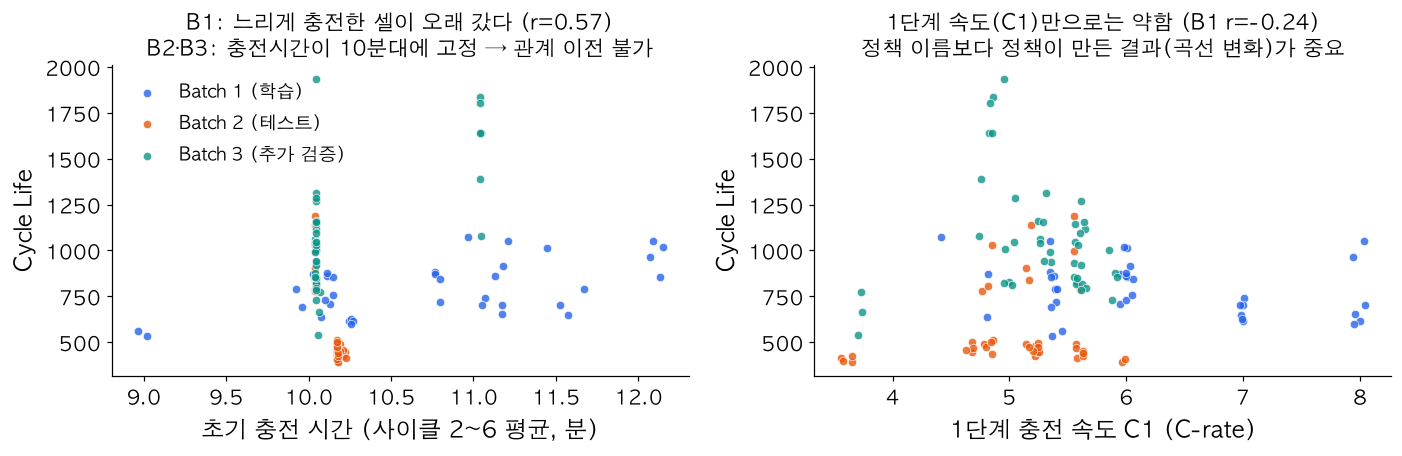

In [7]:
for b in ['b1', 'b2', 'b3']:
    x = used[used.batch == b]
    print(f"{b}: corr(충전시간 2~6, log수명) = {x[['chargetime_2_6','log_life']].corr().iloc[0,1]:.3f} | corr(C1, log수명) = {x[['c1','log_life']].corr().iloc[0,1]:.3f} | 정책 {x.policy.nunique()}종 / {len(x)}셀")
pl = used[used.batch == 'b1'].groupby('policy').cycle_life.agg(['mean', 'count']).sort_values('mean')
print('B1 정책당 셀 수:', pl['count'].value_counts().to_dict()); print(pl.head(3)); print(pl.tail(3))
print(used.groupby('batch').chargetime_2_6.describe().round(2))

fig, ax = plt.subplots(1, 2, figsize=(13, 4.4))
for b in ['b1', 'b2', 'b3']:
    x = used[used.batch == b]
    ax[0].scatter(x.chargetime_2_6, x.cycle_life, s=30, color=BC[b], alpha=0.8, edgecolor='white', lw=0.5, label=BN[b])
    ax[1].scatter(x.c1 + rng.uniform(-0.06, 0.06, len(x)), x.cycle_life, s=30, color=BC[b], alpha=0.8, edgecolor='white', lw=0.5, label=BN[b])
r0 = used[used.batch == 'b1'][['chargetime_2_6', 'log_life']].corr().iloc[0, 1]
r1 = used[used.batch == 'b1'][['c1', 'log_life']].corr().iloc[0, 1]
ax[0].set_xlabel('초기 충전 시간 (사이클 2~6 평균, 분)'); ax[0].set_ylabel('Cycle Life'); ax[0].set_title(f'B1: 느리게 충전한 셀이 오래 갔다 (r={r0:.2f})\nB2·B3: 충전시간이 10분대에 고정 → 관계 이전 불가', fontsize=14)
ax[1].set_xlabel('1단계 충전 속도 C1 (C-rate)'); ax[1].set_ylabel('Cycle Life'); ax[1].set_title(f'1단계 속도(C1)만으로는 약함 (B1 r={r1:.2f})\n정책 이름보다 정책이 만든 결과(곡선 변화)가 중요', fontsize=14)
ax[0].legend(frameon=False, fontsize=12)
plt.tight_layout(); plt.savefig(f'{FIG}/e5_crate.png', dpi=200, bbox_inches='tight'); plt.show()

B1 충전 방식별 평균 수명 (짧은 3개 / 긴 3개)
                 C1  셀   평균수명       C1 구간
policy                                   
5.4C(80%)-5.4C  5.4  2  546.0  5 < C1 ≤ 6
8C(35%)-3.6C    8.0  2  608.0      C1 > 6
7C(40%)-3.6C    7.0  2  621.0      C1 > 6
                 C1  셀    평균수명       C1 구간
policy                                    
6C(30%)-3.6C    6.0  1  1014.0  5 < C1 ≤ 6
5.4C(40%)-3.6C  5.4  1  1054.0  5 < C1 ≤ 6
4.4C(80%)-4.4C  4.4  1  1074.0      C1 ≤ 5

1단계 충전 속도(C1) 구간별 평균 수명 (B1, 셀 단위)
            count   mean    min     max
C1구간                                   
C1 ≤ 5          3  860.0  636.0  1074.0
5 < C1 ≤ 6     21  818.0  534.0  1054.0
C1 > 6         12  719.0  599.0  1051.0


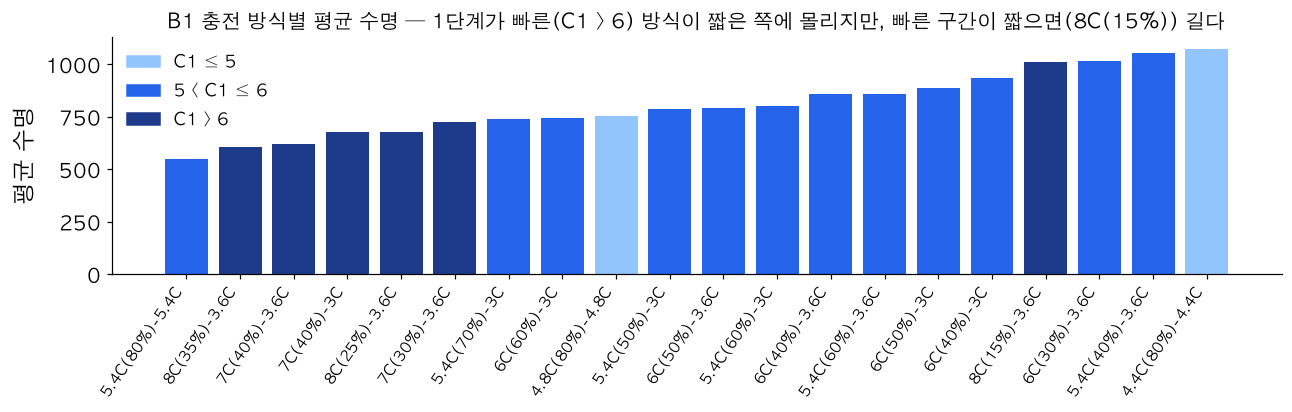

In [8]:
pol = used[used.batch == 'b1'].groupby('policy').agg(C1=('c1', 'first'), 셀=('cycle_life', 'size'), 평균수명=('cycle_life', 'mean')).sort_values('평균수명')
pol['C1 구간'] = pd.cut(pol.C1, [0, 5, 6, 8.1], labels=['C1 ≤ 5', '5 < C1 ≤ 6', 'C1 > 6'])
print('B1 충전 방식별 평균 수명 (짧은 3개 / 긴 3개)'); print(pol.head(3).round({'평균수명': 0}).to_string()); print(pol.tail(3).round({'평균수명': 0}).to_string())
print('\n1단계 충전 속도(C1) 구간별 평균 수명 (B1, 셀 단위)')
b1c = used[used.batch == 'b1'].assign(C1구간=lambda d: pd.cut(d.c1, [0, 5, 6, 8.1], labels=['C1 ≤ 5', '5 < C1 ≤ 6', 'C1 > 6']))
print(b1c.groupby('C1구간', observed=True).cycle_life.agg(['count', 'mean', 'min', 'max']).round(0).to_string())
fig, ax = plt.subplots(figsize=(12, 4))
colmap = {'C1 ≤ 5': '#93c5fd', '5 < C1 ≤ 6': '#2563eb', 'C1 > 6': '#1e3a8a'}
ax.bar(range(len(pol)), pol.평균수명, color=[colmap[c] for c in pol['C1 구간']])
ax.set_xticks(range(len(pol))); ax.set_xticklabels(pol.index, rotation=55, ha='right', fontsize=10)
ax.set_ylabel('평균 수명'); ax.set_title('B1 충전 방식별 평균 수명 — 1단계가 빠른(C1 > 6) 방식이 짧은 쪽에 몰리지만, 빠른 구간이 짧으면(8C(15%)) 길다', fontsize=13)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=col, label=c) for c, col in colmap.items()], frameon=False, fontsize=11)
plt.tight_layout(); plt.savefig(f'{FIG}/e5b_policy_life.png', dpi=200, bbox_inches='tight'); plt.show()

## ⑤ 상관관계 — 어떤 신호가 수명과 연관되는가? 다중공선성은?
- 피처 선택 근거는 **학습 배치(B1)에서만** 계산 (테스트 정보 차단)

dq_var_log        -0.844
dq_min_log        -0.821
dq_mean_log       -0.771
chargetime_2_6     0.575
qd_slope_2_100     0.552
qd_fade_pct_100    0.516
qd_slope_91_100    0.443
dq_skew           -0.434
qd_100             0.353
ir_min             0.345
c1                -0.238
qd_2               0.157
tavg_mean         -0.156
tmax_mean         -0.151
ir_2               0.116
                 dq_var_log  dq_min_log  dq_mean_log  chargetime_2_6  \
dq_var_log             1.00        1.00         0.98           -0.62   
dq_min_log             1.00        1.00         0.99           -0.61   
dq_mean_log            0.98        0.99         1.00           -0.61   
chargetime_2_6        -0.62       -0.61        -0.61            1.00   
qd_slope_2_100        -0.69       -0.70        -0.72            0.56   
qd_fade_pct_100       -0.67       -0.69        -0.72            0.55   
tavg_mean              0.14        0.13         0.09            0.22   
tmax_mean              0.09        0.07         0

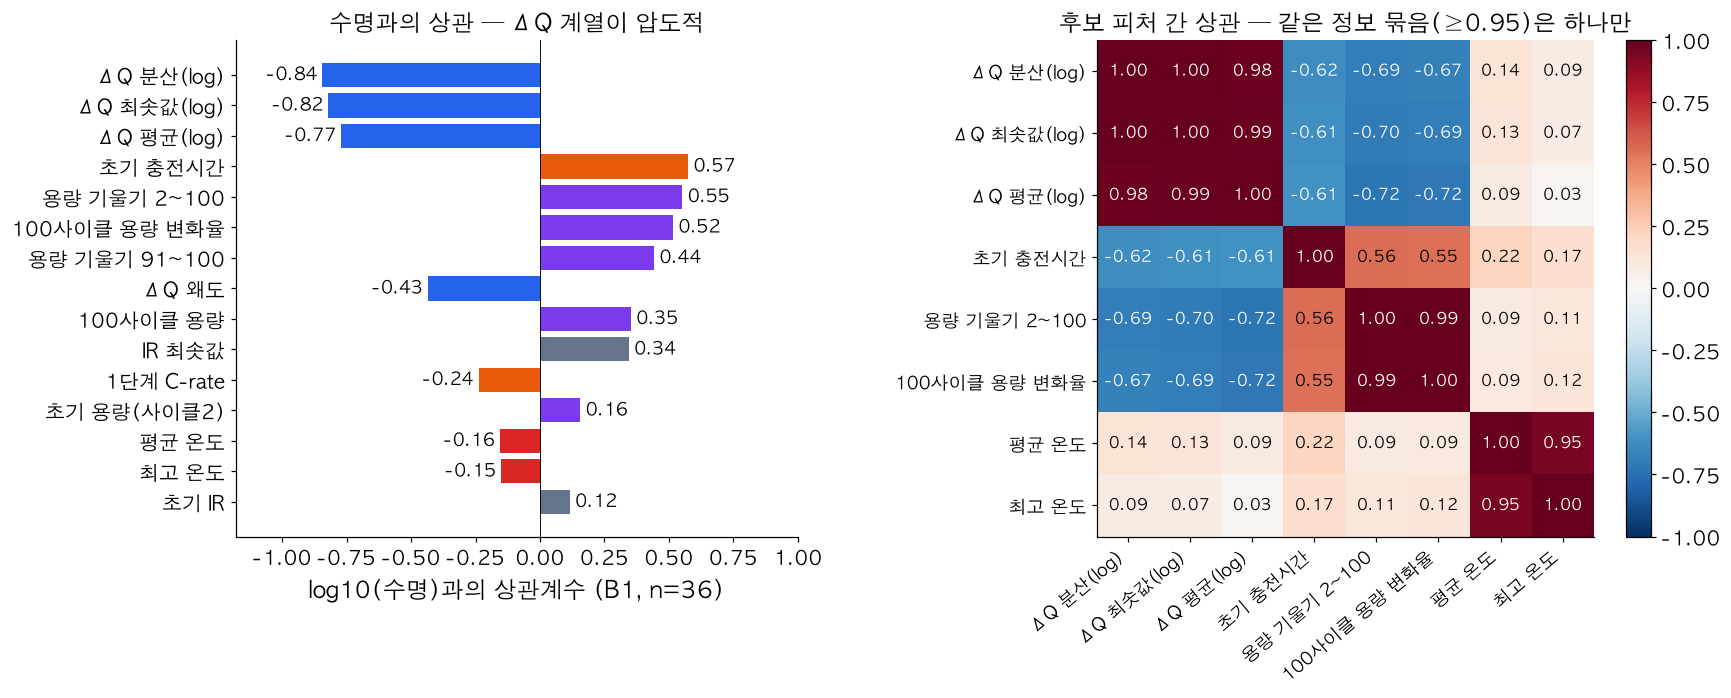

In [9]:
FEATS = {'dq_var_log': 'ΔQ 분산(log)', 'dq_min_log': 'ΔQ 최솟값(log)', 'dq_mean_log': 'ΔQ 평균(log)', 'dq_skew': 'ΔQ 왜도',
         'chargetime_2_6': '초기 충전시간', 'qd_slope_2_100': '용량 기울기 2~100', 'qd_fade_pct_100': '100사이클 용량 변화율',
         'qd_slope_91_100': '용량 기울기 91~100', 'qd_100': '100사이클 용량', 'ir_min': 'IR 최솟값', 'c1': '1단계 C-rate',
         'qd_2': '초기 용량(사이클2)', 'tavg_mean': '평균 온도', 'tmax_mean': '최고 온도', 'ir_2': '초기 IR'}
FAM = {'dq': '#2563eb', 'qd': '#7c3aed', 'charge': '#ea580c', 'temp': '#dc2626', 'ir': '#64748b'}
def fam(f): return FAM['dq'] if f.startswith('dq') else FAM['qd'] if f.startswith('qd') else FAM['charge'] if f in ('chargetime_2_6', 'c1') else FAM['temp'] if f.startswith('t') else FAM['ir']
b1f = used[used.batch == 'b1']
cr = b1f[list(FEATS) + ['log_life']].corr()['log_life'].drop('log_life').sort_values(key=abs)
print(cr.sort_values(key=abs, ascending=False).round(3).to_string())
SEL = ['dq_var_log', 'dq_min_log', 'dq_mean_log', 'chargetime_2_6', 'qd_slope_2_100', 'qd_fade_pct_100', 'tavg_mean', 'tmax_mean']
cm_ = b1f[SEL].corr()
print(cm_.round(2))

fig, ax = plt.subplots(1, 2, figsize=(16, 6.6), gridspec_kw={'width_ratios': [1, 1.15]})
ax[0].barh([FEATS[f] for f in cr.index], cr.values, color=[fam(f) for f in cr.index])
for i, v in enumerate(cr.values): ax[0].text(v + (0.02 if v >= 0 else -0.02), i, f'{v:.2f}', va='center', ha='left' if v >= 0 else 'right', fontsize=12)
ax[0].axvline(0, color='black', lw=0.6); ax[0].set_xlim(-1.18, 1); ax[0].set_xlabel('log10(수명)과의 상관계수 (B1, n=36)')
ax[0].set_title('수명과의 상관 — ΔQ 계열이 압도적')
im = ax[1].imshow(cm_.values, cmap='RdBu_r', vmin=-1, vmax=1)
ax[1].set_xticks(range(len(SEL))); ax[1].set_xticklabels([FEATS[f] for f in SEL], rotation=40, ha='right', fontsize=11.5)
ax[1].set_yticks(range(len(SEL))); ax[1].set_yticklabels([FEATS[f] for f in SEL], fontsize=11.5)
for i in range(len(SEL)):
    for j in range(len(SEL)):
        v = cm_.values[i, j]; ax[1].text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=10.5, color='white' if abs(v) > 0.6 else 'black')
ax[1].set_title('후보 피처 간 상관 — 같은 정보 묶음(≥0.95)은 하나만'); fig.colorbar(im, ax=ax[1], fraction=0.04)
plt.tight_layout(); plt.savefig(f'{FIG}/e6_corr.png', dpi=200, bbox_inches='tight'); plt.show()

## ⑥ 셀 편차 (H5) — 같은 충전 조건이어도 셀마다 수명이 다른가? ΔQ가 그 차이까지 잡는가?
- Batch 1에서 같은 정책으로 2셀 이상 돌린 16개 정책(32셀)만 사용 (학습 데이터만 → 테스트 누수 없음)

정책 16개 / 32셀: 정책이 설명하는 수명 분산 R2 = 0.85
정책 평균으로 예측 MAPE 4.9% | 짝 셀로 예측 MAPE 9.8% | 같은 정책 수명 차이 최대 37%
ΔQ 분산–수명: 정책 간(평균끼리) r = -0.91 | 정책 내(편차끼리) r = -0.10


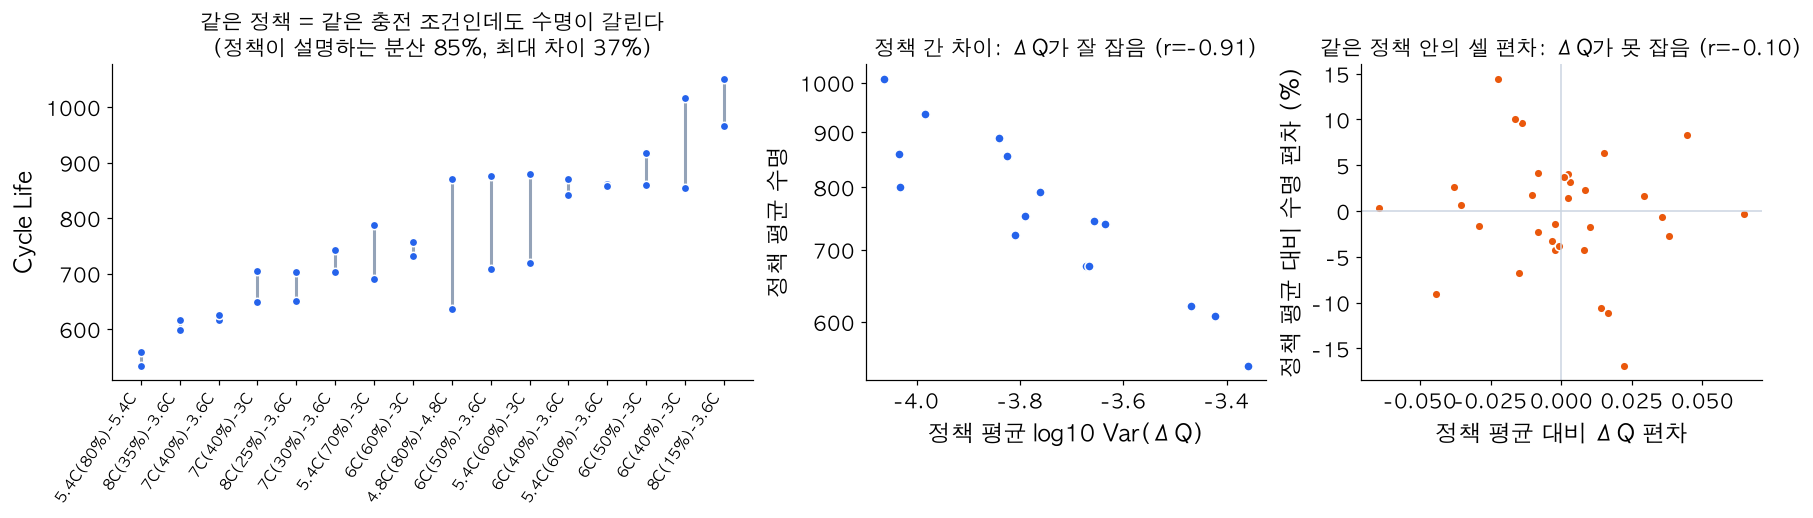

In [10]:
vc = b1f.policy.value_counts(); pp = b1f[b1f.policy.isin(vc[vc >= 2].index)].copy()
pp['pmean'] = pp.groupby('policy').cycle_life.transform('mean')
r2_policy = 1 - ((pp.cycle_life - pp.pmean) ** 2).sum() / ((pp.cycle_life - pp.cycle_life.mean()) ** 2).sum()
mape_pmean = np.mean(np.abs(pp.cycle_life - pp.pmean) / pp.cycle_life) * 100
loo = [abs(r.cycle_life - x.drop(i).cycle_life.mean()) / r.cycle_life * 100 for _, x in pp.groupby('policy') for i, r in x.iterrows()]
pp['life_dev'] = np.log10(pp.cycle_life) - np.log10(pp.pmean)
pp['dq_dev'] = pp.dq_var_log - pp.groupby('policy').dq_var_log.transform('mean')
pm = pp.groupby('policy').agg(dq=('dq_var_log', 'mean'), life=('cycle_life', 'mean'), lo=('cycle_life', 'min'), hi=('cycle_life', 'max')).sort_values('life')
r_between = np.corrcoef(pm.dq, np.log10(pm.life))[0, 1]; r_within = pp[['dq_dev', 'life_dev']].corr().iloc[0, 1]
print(f'정책 {len(pm)}개 / {len(pp)}셀: 정책이 설명하는 수명 분산 R2 = {r2_policy:.2f}')
print(f'정책 평균으로 예측 MAPE {mape_pmean:.1f}% | 짝 셀로 예측 MAPE {np.mean(loo):.1f}% | 같은 정책 수명 차이 최대 {((pm.hi-pm.lo)/pm.lo).max():.0%}')
print(f'ΔQ 분산–수명: 정책 간(평균끼리) r = {r_between:.2f} | 정책 내(편차끼리) r = {r_within:.2f}')

fig, ax = plt.subplots(1, 3, figsize=(16, 4.6), gridspec_kw={'width_ratios': [1.6, 1, 1]}, constrained_layout=True)
xs_ = np.arange(len(pm))
ax[0].vlines(xs_, pm.lo, pm.hi, color='#94a3b8', lw=2)
for i, (pol, row) in enumerate(pm.iterrows()):
    v = pp[pp.policy == pol].cycle_life.values
    ax[0].scatter([i] * len(v), v, color='#2563eb', s=30, zorder=3, edgecolor='white')
ax[0].set_xticks(xs_); ax[0].set_xticklabels(pm.index, rotation=55, ha='right', fontsize=10)
ax[0].set_ylabel('Cycle Life'); ax[0].set_title(f'같은 정책 = 같은 충전 조건인데도 수명이 갈린다\n(정책이 설명하는 분산 {r2_policy:.0%}, 최대 차이 {((pm.hi-pm.lo)/pm.lo).max():.0%})', fontsize=14)
ax[1].scatter(pm.dq, pm.life, color='#2563eb', s=36, edgecolor='white'); ax[1].set_yscale('log'); ax[1].set_yticks([600, 700, 800, 900, 1000]); ax[1].set_yticklabels(['600', '700', '800', '900', '1000']); ax[1].minorticks_off()
ax[1].set_xlabel('정책 평균 log10 Var(ΔQ)'); ax[1].set_ylabel('정책 평균 수명'); ax[1].set_title(f'정책 간 차이: ΔQ가 잘 잡음 (r={r_between:.2f})', fontsize=14)
ax[2].axhline(0, color='#cbd5e1', lw=1); ax[2].axvline(0, color='#cbd5e1', lw=1)
ax[2].scatter(pp.dq_dev, pp.life_dev * 100 * np.log(10), color='#ea580c', s=32, edgecolor='white')
ax[2].set_xlabel('정책 평균 대비 ΔQ 편차'); ax[2].set_ylabel('정책 평균 대비 수명 편차 (%)'); ax[2].set_title(f'같은 정책 안의 셀 편차: ΔQ가 못 잡음 (r={r_within:.2f})', fontsize=14)
plt.savefig(f'{FIG}/e7_cell_variation.png', dpi=200, bbox_inches='tight'); plt.show()

## 정리 — 가설 검증 → 모델 전략
| 가설 | 판정 | EDA 근거 | 모델링 결정 |
|---|---|---|---|
| H4 초기엔 곡선 모양이 먼저 변한다 | 채택 | 용량 변화 +0.22% vs log Var(ΔQ) r = -0.84 | ΔQ 분산 핵심 피처, log10 Target |
| H5 같은 조건이어도 셀 편차 | 채택 | 정책 R2 0.85, 정책 내 편차는 ΔQ로 설명 안 됨(r = -0.10) | 성능 기대치 5~10% |
| H1 충전이 빠를수록 짧다 | 부분 지지 | B1 r = 0.58, B2·B3 충전시간 입력값 10분대 고정 | 충전시간 제외 |
| H2 저항이 클수록 짧다 | 초기엔 신호 없음 | IR 평탄, r = 0.12~0.34 | 보조 후보 |
| H3 온도가 높을수록 짧다 | 확인 불가 | 온도 30.4~33.9℃로 좁음, r = -0.16 | 보조 후보 |
- 데이터 처리: B1 EOL 미도달 10셀·라벨 없는 셀 제외 → B1 36 / B2 39 / B3 44셀, 측정 오류만 처리하고 극단값은 유지
- 리스크: B2의 77%가 학습 범위 밖(외삽) + 같은 ΔQ에서 수명이 더 짧은 기준선 이동 → 과대예측 방향 분석

## 5가지 질문 — 핵심 발견
| 질문 | 핵심 발견 | 모델링으로 |
|---|---|---|
| ① 수명 분포 | B1 534 ~ 1,074 (단수명 <500: 0, 장수명 >1,000: 5/36) · B2 단수명 28/39, **77%가 학습 최솟값 아래** · B3 장수명 23/44 | 배치마다 분포가 다르다 → 학습 범위 밖까지 이어지는 선형 계열 |
| ② 열화 곡선 | 100사이클까지 용량 변화 +0.22% · Knee ≈ 수명 × 0.75 (r = 0.98) · Knee 이후 열화 10.5배 빠름 | 용량 값 대신 곡선 모양 |
| ③ ΔQ(V) | log Var(ΔQ) ↔ log 수명 r = −0.84 / −0.92 / −0.76 (B1 / B2 / B3) | 핵심 피처 |
| ④ 충전 조건 | B1 충전 시간 r = 0.58, C1 r = −0.24 (C1 > 6 평균 719 vs C1 ≤ 5 평균 860) · B2 · B3 충전 시간은 10.0 ~ 10.2분에 몰림 | 충전 영향은 ΔQ에 반영 → 충전 시간 제외 (02 노트북 5절) |
| ⑤ 상관 · 다중공선성 | ΔQ 계열이 가장 강함 · ΔQ 분산 ↔ 최솟값 1.00, ↔ 평균 0.98 | ΔQ 계열은 분산 하나만 |